# Rail launch to LEO and a finite-burn Hohmann transfer to GEO

Every powered segment in this notebook uses an ordinary `Rocket` and
`GenericMotor`. The ascent is one continuous 13-state, 6DOF `Flight` from the
rail. Its motor uses an open-loop thrust-vector schedule. The two transfer
manoeuvres are finite axial burns by fixed-attitude 6DOF stages: there is no
custom acceleration model, guidance object, ideal impulse, or velocity-state
replacement.

`Earth.datum` owns all kinematic transformations. Local `Environment` data is
only the lowest layer of the composed atmosphere.

In [1]:
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np

from rocketpy import (
    Atmosphere,
    Datum,
    Earth,
    EarthRadiationPressure,
    Environment,
    Epoch,
    NRLMSISE00AtmosphereLayer,
    Flight,
    FlightState,
    GenericMotor,
    Rocket,
    Space,
)


## Earth and Space

The point-mass geopotential keeps the transfer geometry easy to inspect while
the full datum still supplies rotating-Earth launch kinematics. `Space`
prepares its shared SPICE ephemeris before any Flight integration. Earth
radiation pressure is installed as an explicit Earth-owned model.

In [2]:
SIDEREAL_DAY = 86_164.0905
BURN_TIME = 400.0
BOOST_END = 50.0

epoch = Epoch.from_datetime(datetime(2026, 1, 1, 18, tzinfo=UTC))
launch_weather = Environment(
    date=epoch.to_datetime(),
    latitude=0.0,
    longitude=-60.7,
    elevation=0.0,
)
space = Space(["sun", "moon"])
sun = next(body for body in space.bodies if body.name == "sun")
earth = Earth(
    datum=Datum(),
    geopotential="egm2008",
    atmosphere=Atmosphere(
        {-np.inf: launch_weather, 80_000.0: NRLMSISE00AtmosphereLayer()},
        transition_width=10_000.0,
    ),
    albedo=EarthRadiationPressure(sun),
    relativistic_correction=True,
)


/tmp/ipykernel_710365/1028180334.py:6: UserWarning: Environment.datum is retained exclusively for local weather and geodetic compatibility. It does not select Flight's kinematic datum; use Earth.datum for rotating or orbital simulations.
  launch_weather = Environment(


## Physical ascent vehicle

The conceptual SSTO starts at 205 tonnes and burns down to 25 tonnes. Its
optimistic motor has a 4 MN boost plateau followed by a 1.68 MN sustainer.
Chamber, dry center of mass, and gimbal pivot are colocated so the thrust
vector passes through the center of mass.

In [3]:
ascent_motor = GenericMotor(
    thrust_source=np.array(
        [
            [0.0, 4.00e6],
            [BOOST_END, 4.00e6],
            [BOOST_END + 0.1, 1.68e6],
            [BURN_TIME, 1.68e6],
        ]
    ),
    burn_time=BURN_TIME,
    chamber_radius=1.5,
    chamber_height=25.0,
    chamber_position=0.0,
    propellant_initial_mass=180_000.0,
    nozzle_radius=1.2,
    dry_mass=5_000.0,
    center_of_dry_mass_position=0.0,
    dry_inertia=(1.0e6, 1.0e6, 5.0e4),
    nozzle_position=0.0,
)
ascent_vehicle = Rocket(
    radius=1.8,
    mass=20_000.0,
    inertia=(1.0e7, 1.0e7, 5.0e5),
    power_off_drag=0.12,
    power_on_drag=0.12,
    center_of_mass_without_motor=0.0,
)
ascent_vehicle.add_motor(ascent_motor, position=0.0)
ascent_vehicle.set_orbital_drag_model(0.12, np.pi * ascent_vehicle.radius**2)
ascent_vehicle.set_radiation_properties(1.0, np.pi * ascent_vehicle.radius**2)


## Open-loop motor steering and 6DOF ascent

This pitch table commands the actual motor thrust vector. It is a predetermined
schedule rather than a force injected into `Flight`; `ascent_flight.forces`
therefore remains empty.

In [4]:
pitch_time = np.array(
    [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 250, 300, 350, 400],
    dtype=float,
)
pitch_angle = np.deg2rad(
    [
        88.6,
        88.0,
        86.4,
        83.6,
        81.0,
        76.5,
        70.7,
        63.1,
        54.2,
        44.7,
        27.1,
        14.3,
        6.1,
        1.6,
        0.15,
    ]
)


def body_to_gcrf_matrix(quaternion):
    q0, q1, q2, q3 = quaternion
    return np.array(
        [
            [
                1 - 2 * (q2**2 + q3**2),
                2 * (q1 * q2 - q0 * q3),
                2 * (q1 * q3 + q0 * q2),
            ],
            [
                2 * (q1 * q2 + q0 * q3),
                1 - 2 * (q1**2 + q3**2),
                2 * (q2 * q3 - q0 * q1),
            ],
            [
                2 * (q1 * q3 - q0 * q2),
                2 * (q2 * q3 + q0 * q1),
                1 - 2 * (q1**2 + q2**2),
            ],
        ]
    )


def ascent_tvc_direction(time, state):
    radial = state.position / np.linalg.norm(state.position)
    normal = np.cross(state.position, state.velocity)
    normal /= np.linalg.norm(normal)
    prograde = np.cross(normal, radial)
    prograde /= np.linalg.norm(prograde)
    pitch = np.interp(time, pitch_time, pitch_angle)
    desired_gcrf = np.sin(pitch) * radial + np.cos(pitch) * prograde
    return body_to_gcrf_matrix(state.quaternion).T @ desired_gcrf


ascent_motor.set_thrust_direction(ascent_tvc_direction)
ascent_flight = Flight.from_launch(
    ascent_vehicle,
    earth,
    rail_length=30.0,
    inclination=88.6,
    heading=90.0,
    space=space,
    max_time=BURN_TIME,
    simulation_mode="6DOF",
    max_time_step=BURN_TIME // 25,
    rtol=1e-7,
    atol=1e-4,
    ode_solver="LSODA",
)


In [5]:
insertion = ascent_flight.orbit.at_time(BURN_TIME)
earth_radius = earth.datum.a
print(f"Rail exit:               {ascent_flight.out_of_rail_time:10.3f} s")
print(f"Cutoff altitude:         {ascent_flight.altitude(BURN_TIME) / 1e3:10.2f} km")
print(f"Insertion eccentricity:  {insertion.eccentricity:10.6f}")
print(f"Insertion perigee:        {(ascent_flight.orbit.periapsis_radius(BURN_TIME) - earth_radius) / 1e3:10.2f} km")
print(f"Insertion apogee:         {(ascent_flight.orbit.apoapsis_radius(BURN_TIME) - earth_radius) / 1e3:10.2f} km")
print("Ascent custom forces:    ", ascent_flight.forces)


Rail exit:                    2.468 s
Cutoff altitude:             180.38 km
Insertion eccentricity:    0.005303
Insertion perigee:            161.93 km
Insertion apogee:             231.67 km
Ascent custom forces:     []


## Fixed-attitude finite burns

Each transfer stage is rotated once so its body `+z` axis is prograde. The
motor then burns axially through the center of mass with no in-flight steering.
The helper sizes propellant from the requested ideal delta-v and a didactic
450 s specific impulse; the numerical Flight determines the achieved orbit.
Coast legs use unpowered Rockets of the corresponding dry mass.

In [6]:
def prograde_direction(state):
    normal = np.cross(state.position, state.velocity)
    normal /= np.linalg.norm(normal)
    transverse = np.cross(normal, state.position)
    return transverse / np.linalg.norm(transverse)


def quaternion_aligning_body_z(direction):
    direction = np.asarray(direction, dtype=float)
    direction /= np.linalg.norm(direction)
    body_z = np.array([0.0, 0.0, 1.0])
    cosine = np.dot(body_z, direction)
    if cosine < -1.0 + 1e-12:
        return np.array([0.0, 1.0, 0.0, 0.0])
    quaternion = np.r_[np.sqrt(0.5 * (1.0 + cosine)), np.cross(body_z, direction) / np.sqrt(2.0 * (1.0 + cosine))]
    return quaternion / np.linalg.norm(quaternion)


def reset_leg_state(state, *, align_prograde=False):
    quaternion = (
        quaternion_aligning_body_z(prograde_direction(state))
        if align_prograde
        else state.quaternion
    )
    return FlightState.cartesian(
        epoch=state.epoch,
        position=state.position,
        velocity=state.velocity,
        quaternion=quaternion,
        angular_velocity=np.zeros(3),
        frame=state.frame,
        elapsed_time=0.0,
    )


def make_orbital_vehicle(name, delta_v=0.0, burn_duration=20.0):
    del name
    dry_vehicle_mass = 8_000.0
    dry_motor_mass = 2_000.0
    dry_mass = dry_vehicle_mass + dry_motor_mass
    effective_exhaust_velocity = 450.0 * 9.80665
    propellant_mass = dry_mass * (np.exp(delta_v / effective_exhaust_velocity) - 1.0)
    thrust = (
        propellant_mass * effective_exhaust_velocity / burn_duration
        if propellant_mass > 0.0
        else 0.0
    )
    motor = GenericMotor(
        thrust_source=np.array([[0.0, thrust], [burn_duration, thrust]]),
        burn_time=burn_duration,
        chamber_radius=1.0,
        chamber_height=5.0,
        chamber_position=0.0,
        propellant_initial_mass=propellant_mass,
        nozzle_radius=0.8,
        dry_mass=dry_motor_mass,
        center_of_dry_mass_position=0.0,
        dry_inertia=(2.0e4, 2.0e4, 5.0e3),
        nozzle_position=0.0,
    )
    vehicle = Rocket(
        radius=1.5,
        mass=dry_vehicle_mass,
        inertia=(8.0e4, 8.0e4, 1.0e4),
        power_off_drag=0.0,
        power_on_drag=0.0,
        center_of_mass_without_motor=0.0,
    )
    vehicle.add_motor(motor, position=0.0)
    vehicle.set_orbital_drag_model(2.2, np.pi * vehicle.radius**2)
    vehicle.set_radiation_properties(1.0, np.pi * vehicle.radius**2)
    return vehicle, motor


def make_coast_vehicle():
    vehicle = Rocket(
        radius=1.5,
        mass=10_000.0,
        inertia=(1.0e5, 1.0e5, 1.5e4),
        power_off_drag=0.0,
        power_on_drag=0.0,
        center_of_mass_without_motor=0.0,
    )
    vehicle.set_orbital_drag_model(2.2, np.pi * vehicle.radius**2)
    vehicle.set_radiation_properties(1.0, np.pi * vehicle.radius**2)
    return vehicle


In [7]:
leo_state = ascent_flight.state_at_time(BURN_TIME)
mu = earth.datum.GM
leo_radius = np.linalg.norm(leo_state.position)
geo_radius = (mu * (SIDEREAL_DAY / (2.0 * np.pi)) ** 2) ** (1.0 / 3.0)
transfer_a = 0.5 * (leo_radius + geo_radius)
transfer_perigee_speed = np.sqrt(mu * (2.0 / leo_radius - 1.0 / transfer_a))
current_transverse_speed = np.linalg.norm(
    np.cross(leo_state.position, leo_state.velocity)
) / leo_radius
delta_v_1 = transfer_perigee_speed - current_transverse_speed

burn_duration = 20.0
transfer_vehicle, transfer_motor = make_orbital_vehicle(
    "Transfer stage", delta_v_1, burn_duration
)
first_burn = Flight.from_orbit(
    transfer_vehicle,
    earth,
    reset_leg_state(leo_state, align_prograde=True),
    space=space,
    duration=burn_duration,
    simulation_mode="6DOF",
    max_time_step=burn_duration / 25,
    rtol=1e-8,
    atol=1e-5,
    ode_solver="LSODA",
)

transfer_start = first_burn.state_at_time(first_burn.t_final)
transfer_time = np.pi * np.sqrt(transfer_a**3 / mu)
coast_vehicle = make_coast_vehicle()
transfer_coast = Flight.from_orbit(
    coast_vehicle,
    earth,
    reset_leg_state(transfer_start),
    space=space,
    duration=transfer_time - burn_duration / 2.0,
    simulation_mode="6DOF",
    max_time_step=(transfer_time - burn_duration / 2.0) // 25,
    rtol=2e-9,
    atol=1e-5,
    ode_solver="LSODA",
)

apogee_state = transfer_coast.state_at_time(transfer_coast.t_final)
apogee_radius = np.linalg.norm(apogee_state.position)
current_apogee_speed = np.linalg.norm(
    np.cross(apogee_state.position, apogee_state.velocity)
) / apogee_radius
geo_speed = np.sqrt(mu / apogee_radius)
delta_v_2 = geo_speed - current_apogee_speed
geo_vehicle, geo_motor = make_orbital_vehicle(
    "Circularization stage", delta_v_2, burn_duration
)
second_burn = Flight.from_orbit(
    geo_vehicle,
    earth,
    reset_leg_state(apogee_state, align_prograde=True),
    space=space,
    duration=burn_duration,
    simulation_mode="6DOF",
    max_time_step=burn_duration / 25,
    rtol=1e-8,
    atol=1e-5,
    ode_solver="LSODA",
)

geo_start = second_burn.state_at_time(second_burn.t_final)
geo_coast_vehicle = make_coast_vehicle()
geo_flight = Flight.from_orbit(
    geo_coast_vehicle,
    earth,
    reset_leg_state(geo_start),
    space=space,
    duration=2 * SIDEREAL_DAY,
    simulation_mode="6DOF",
    max_time_step=(2 * SIDEREAL_DAY) // 25,
    rtol=2e-9,
    atol=1e-5,
    ode_solver="LSODA",
)


In [11]:
print(f"Nominal first burn delta-v:  {delta_v_1 / 1e3:10.3f} km/s")
print(f"Nominal second burn delta-v: {delta_v_2 / 1e3:10.3f} km/s")
print(f"Transfer coast:              {transfer_time / 3600:10.3f} h")
print(f"Final semimajor axis:        {geo_flight.orbit.final.semi_major_axis / 1e3:10.2f} km")
print(f"Final eccentricity:          {geo_flight.orbit.final.eccentricity:10.6f}")
print(f"Final geodetic altitude:     {geo_flight.altitude(geo_flight.t_final) / 1e3:10.2f} km")
print("Custom forces by powered leg:", ascent_flight.forces, first_burn.forces, second_burn.forces)

assert ascent_flight.simulation_mode == first_burn.simulation_mode == second_burn.simulation_mode == "6DOF"
assert ascent_flight.forces == first_burn.forces == second_burn.forces == []
assert np.linalg.norm(transfer_motor.net_thrust_vector(burn_duration / 2)) > 0.0
assert np.linalg.norm(geo_motor.net_thrust_vector(burn_duration / 2)) > 0.0
assert geo_flight.orbit.final.eccentricity < 0.01
assert abs(geo_flight.orbit.final.semi_major_axis - geo_radius) < 100_000.0


Nominal first burn delta-v:       2.451 km/s
Nominal second burn delta-v:      1.479 km/s
Transfer coast:                   5.256 h
Final semimajor axis:          41969.08 km
Final eccentricity:            0.006866
Final geodetic altitude:       35561.52 km
Custom forces by powered leg: [] [] []


AssertionError: 

## Launch-local and orbital views

The ascent panel uses launch-local coordinates from the same inertial
integration. The remaining panels show the transfer and the final GEO coast.

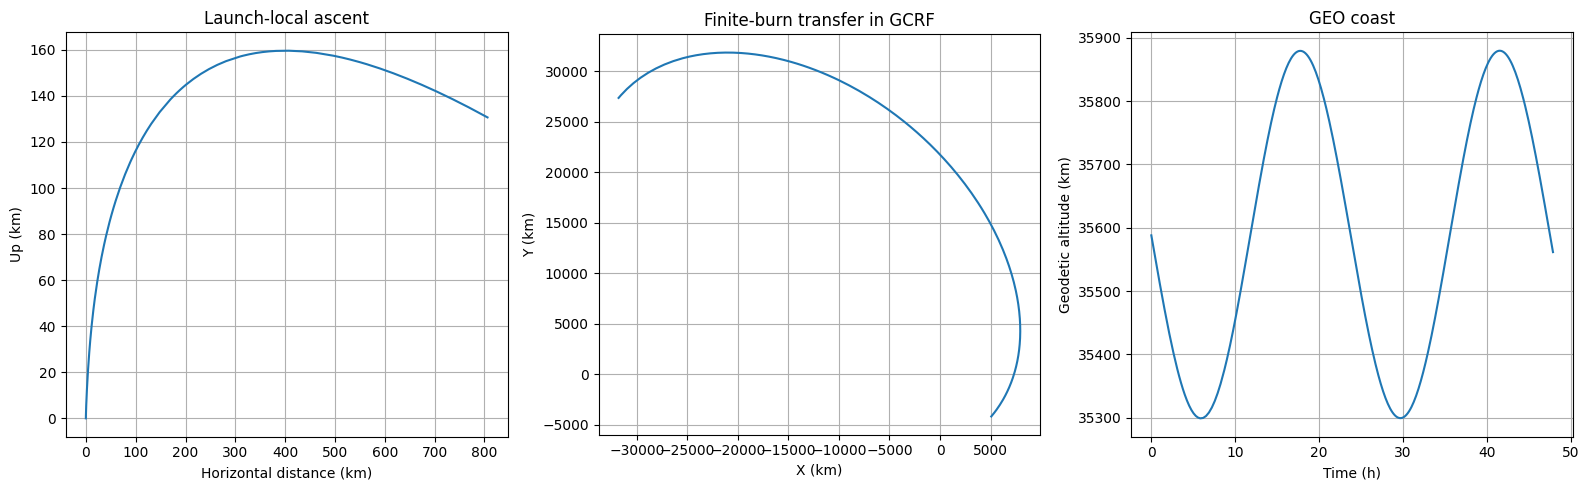

In [9]:
local_ascent = ascent_flight.position_local()
figure, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(
    np.hypot(local_ascent[:, 0], local_ascent[:, 1]) / 1e3,
    local_ascent[:, 2] / 1e3,
)
axes[0].set(
    title="Launch-local ascent",
    xlabel="Horizontal distance (km)",
    ylabel="Up (km)",
)
transfer_position = transfer_coast.position("gcrf")
axes[1].plot(transfer_position[:, 0] / 1e3, transfer_position[:, 1] / 1e3)
axes[1].set(
    title="Finite-burn transfer in GCRF",
    xlabel="X (km)",
    ylabel="Y (km)",
    aspect="equal",
)
axes[2].plot(geo_flight.time / 3600, geo_flight.altitude[:, 1] / 1e3)
axes[2].set(
    title="GEO coast",
    xlabel="Time (h)",
    ylabel="Geodetic altitude (km)",
)
for axis in axes:
    axis.grid(True)
figure.tight_layout()


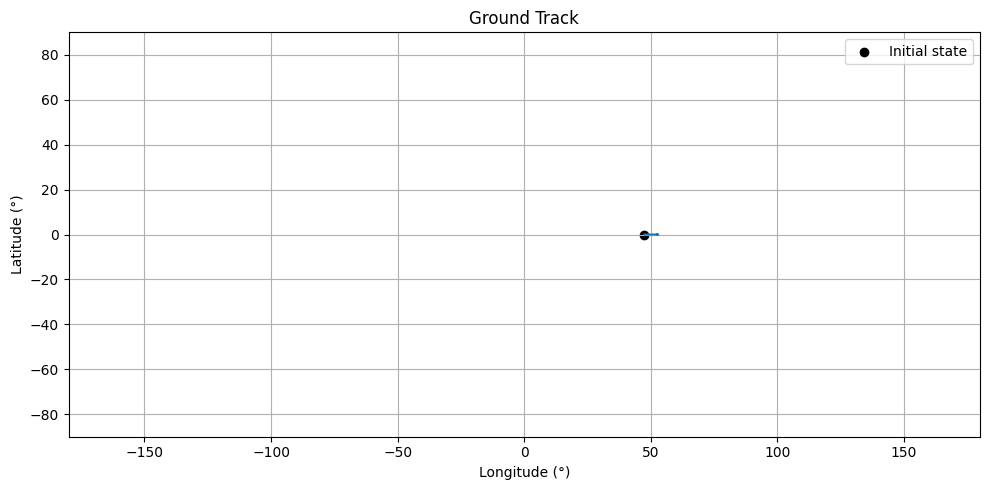

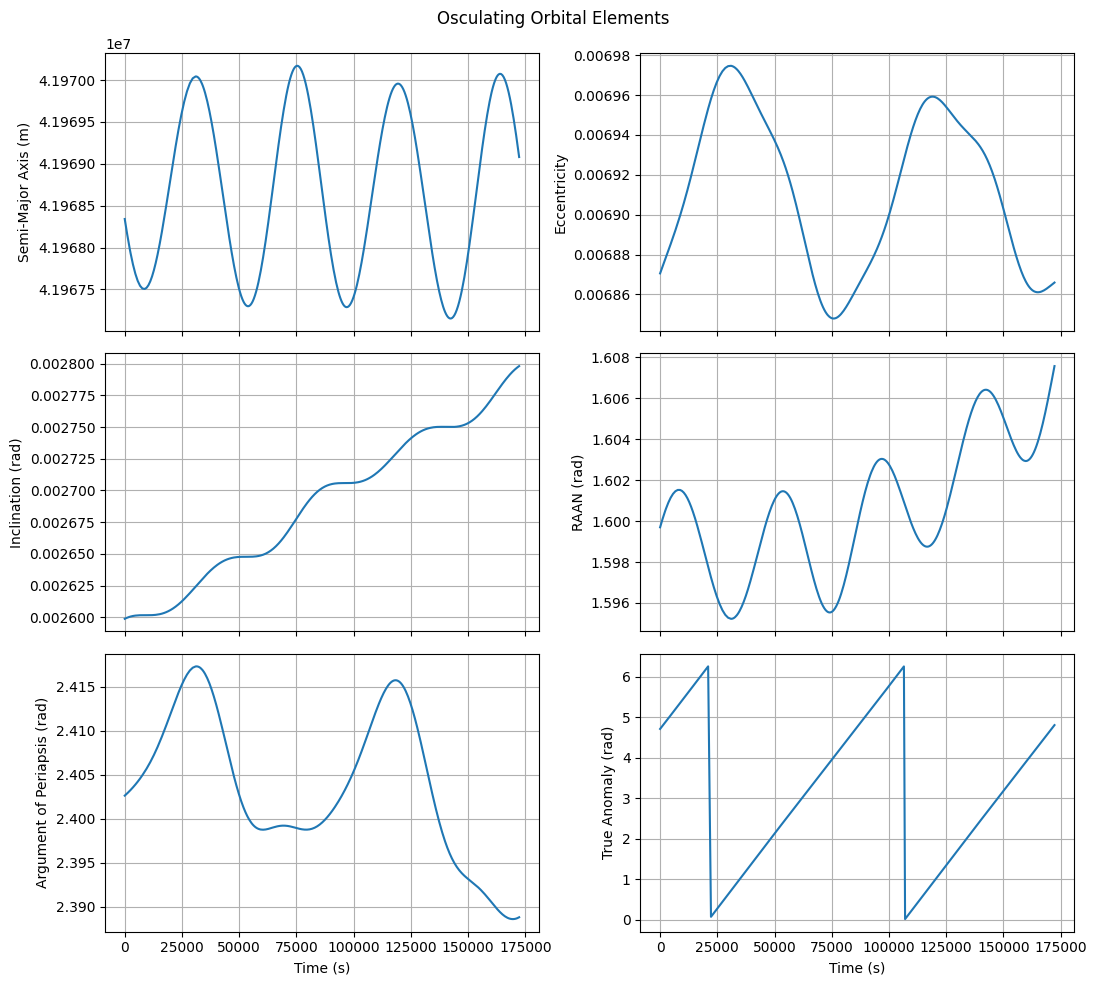

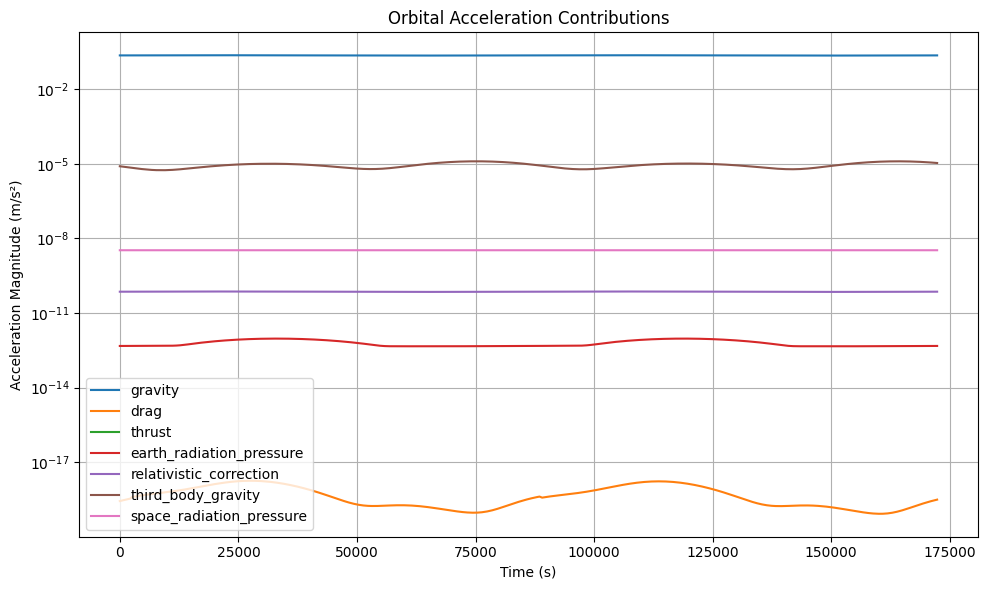

In [10]:
geo_flight.plots.orbit_3d(backend="plotly")
geo_flight.plots.ground_track()
geo_flight.plots.orbital_elements()
geo_flight.plots.orbital_acceleration_components()
